In [48]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
    module="pkg_resources"
)

import numpy as np
import json
import os
import time

from deqart_internal import pauli_path_gpu
from bluequbit.library.helpers.hardware_connectivites import IBM_127_HEAVY_HEX_MAP
from qiskit import QuantumCircuit

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [49]:
# ── Parameters ────────────────────────────────────────────────────────────────
num_qubits        = 127
num_trotter_steps = 20
rzz_angle         = -np.pi / 2
rx_angle          = np.pi / 4

deltas = [
    1.0e-2,
    5.0e-3,
    1.0e-3,
    5.0e-4,
    1.0e-4,
    5.0e-5,
    2.5e-5,
    1.0e-5,
    9.0e-6,
    8.0e-6,
    7.0e-6,
    6.0e-6,
    5.0e-6,
    4.5e-6
]
delta_labels = [
    "1.00E-02",
    "5.00E-03",
    "1.00E-03",
    "5.00E-04",
    "1.00E-04",
    "5.00E-05",
    "2.50E-05",
    "1.00E-05",
    "9.00E-06",
    "8.00E-06",
    "7.00E-06",
    "6.00E-06",
    "5.00E-06",
    "4.50E-06",
]

# ── Observable <Z_62> ─────────────────────────────────────────────────────────
pauli_str = "I" * (num_qubits - 1 - 62) + "Z" + "I" * 62
pauli_sum = [(pauli_str, 1.0)]

BILLION = 1_000_000_000

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_FILE = os.path.join("..", "data", "pps_gpu_benchmark.jsonl")
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)


In [50]:
# ── Resume support ────────────────────────────────────────────────────────────
completed = {}
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            try:
                r = json.loads(line)
                if r.get("status") == "ok":
                    completed[r["delta"]] = r
            except Exception:
                pass
    print(f"Resuming: {len(completed)} runs already complete.")
else:
    with open(OUTPUT_FILE, "w") as f:
        f.write(f"# Extended sweep theta_x=pi/4  num_qubits={num_qubits}  steps={num_trotter_steps}\n")
        f.write(f"# deltas={delta_labels}\n")
    print("Starting fresh.")

Starting fresh.


In [51]:
# ── Build circuit ─────────────────────────────────────────────────────────────
print("Building circuit...")
qc = QuantumCircuit(num_qubits)
for _ in range(num_trotter_steps):
    for edge in IBM_127_HEAVY_HEX_MAP:
        qc.rzz(rzz_angle, edge[0], edge[1])
    for i in range(num_qubits):
        qc.rx(rx_angle, i)
print(f"Depth: {qc.depth()}  Gates: {qc.size()}")

Building circuit...
Depth: 98  Gates: 5420


In [52]:
# ── Sweep ─────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"{'δ':<12} {'<Z_62>':<14} {'Max Paulis':>16}  {'Time (s)':>10}  Status")
print("-" * 65)

records = dict(completed)

for delta, label in zip(deltas, delta_labels):

    if delta in records:
        r = records[delta]
        marker = "OVER 1B!" if r["max_paulis"] >= BILLION else "skip"
        print(f"{label:<12} {r['expectation_value']:<14.6f} {r['max_paulis']:>16,}  {r['run_time_s']:>9.1f}s  ✓ {marker}")
        continue

    print(f"{label:<12} running...", end="", flush=True)
    try:
        exp_val, num_paulis_hist, gate_times, _, _ = pauli_path_gpu.get_expectation_value(
            qc,
            pauli_sum,
            truncation_threshold=delta,
            return_internal_stats=True,
        )

        max_paulis = max(num_paulis_hist)
        ev         = float(np.real(exp_val))
        run_time_s = sum(gate_times)  # gate_times is s per layer

        record = {
            "delta":             delta,
            "delta_label":       label,
            "expectation_value": ev,
            "max_paulis":        int(max_paulis),
            "num_paulis_hist":   [int(x) for x in num_paulis_hist],
            "gate_times_ms":     [float(x) for x in gate_times],
            "run_time_s":        run_time_s,
            "rx_angle":          rx_angle,
            "num_qubits":        num_qubits,
            "num_trotter_steps": num_trotter_steps,
            "observable":        "Z_62",
            "status":            "ok",
        }
        records[delta] = record

        with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
            f.flush()
            os.fsync(f.fileno())

        over_marker = "  ◀ OVER 1B!" if max_paulis >= BILLION else ""
        print(f"\r{label:<12} {ev:<14.6f} {max_paulis:>16,}  {run_time_s:>9.1f}s  ✓{over_marker}")

    except Exception as e:
        err_record = {"delta": delta, "delta_label": label,
                      "error": str(e), "status": "error"}
        records[delta] = err_record
        with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
            f.write(json.dumps(err_record) + "\n")
            f.flush()
        print(f"\r{label:<12} {'ERROR':<14} {'—':>16}  {'—':>10}s  ✗  {e}")

print(f"\nResults saved → {OUTPUT_FILE}")


δ            <Z_62>               Max Paulis    Time (s)  Status
-----------------------------------------------------------------
1.00E-02     0.257952                    664       13.3s  ✓
5.00E-03     0.280520                  2,265       15.0s  ✓
1.00E-03     0.249176                 33,143       20.5s  ✓
5.00E-04     0.218300                115,667       22.2s  ✓
1.00E-04     0.156208              2,166,786       37.9s  ✓
5.00E-05     0.151976              7,566,013       47.4s  ✓
2.50E-05     0.171395             27,570,927       60.0s  ✓
1.00E-05     0.215664            149,411,103      131.5s  ✓
9.00E-06     0.221244            181,362,123      152.0s  ✓
8.00E-06     0.227857            226,590,774      180.3s  ✓
7.00E-06     0.234860            291,693,307      224.0s  ✓
6.00E-06     0.243193            390,125,351      297.5s  ✓
5.00E-06     0.252135            549,853,786      433.0s  ✓
4.50E-06     0.257441            662,823,961      724.5s  ✓

Results saved → data/pps_gp

In [47]:
# ── Find 1B crossing ──────────────────────────────────────────────────────────
ok = sorted(
    [r for r in records.values() if r.get("status") == "ok"],
    key=lambda r: r["delta"], reverse=True
)

crossed = [r for r in ok if r["max_paulis"] >= BILLION]
below   = [r for r in ok if r["max_paulis"] <  BILLION]

print(f"\n{'='*60}")
print(f"{'1 BILLION PAULI STRING CROSSING':^60}")
print(f"{'='*60}")
if crossed and below:
    first_over = min(crossed, key=lambda r: r["max_paulis"])
    last_under = max(below,   key=lambda r: r["max_paulis"])
    print(f"  Last BELOW 1B : δ = {last_under['delta_label']}  →  {last_under['max_paulis']:>14,}")
    print(f"  First OVER 1B : δ = {first_over['delta_label']}  →  {first_over['max_paulis']:>14,}")
    print(f"\n  ➤ Crossing between δ = {last_under['delta_label']} and δ = {first_over['delta_label']}")
elif crossed:
    print("  All points OVER 1B — sweep to larger δ to find lower bound.")
else:
    print("  No points crossed 1B yet — sweep to smaller δ.")
    closest = max(ok, key=lambda r: r["max_paulis"])
    print(f"  Closest: δ = {closest['delta_label']}  →  {closest['max_paulis']:,}")
print(f"{'='*60}")


              1 BILLION PAULI STRING CROSSING               
  No points crossed 1B yet — sweep to smaller δ.
  Closest: δ = 4.50E-06  →  662,823,961


In [40]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'='*65}")
print(f"{'SUMMARY':^65}")
print(f"{'='*65}")
print(f"{'δ':<12} {'<Z_62>':<14} {'Max Paulis':>16}  {'Time (s)':>10}")
print("-" * 65)
for r in ok:
    flag = "  ◀ OVER" if r["max_paulis"] >= BILLION else ""
    print(f"{r['delta_label']:<12} {r['expectation_value']:<14.6f} {r['max_paulis']:>16,}  {r['run_time_s']:>9.1f}s{flag}")
print(f"{'='*65}")

                             SUMMARY                             
δ            <Z_62>               Max Paulis    Time (s)
-----------------------------------------------------------------
1.00E-02     0.257952                    664       13.3s
5.00E-03     0.280520                  2,265       15.0s
1.00E-03     0.249176                 33,143       20.4s
5.00E-04     0.218300                115,667       22.2s
1.00E-04     0.156208              2,166,786       37.7s
5.00E-05     0.151976              7,566,013       47.5s
2.50E-05     0.171395             27,570,927       59.7s
1.00E-05     0.215664            149,411,103      131.1s
9.00E-06     0.221244            181,362,123      151.4s
8.00E-06     0.227857            226,590,774      180.4s
7.00E-06     0.234860            291,693,307      223.9s
6.00E-06     0.243193            390,125,351      297.6s
5.00E-06     0.252135            549,853,786      433.2s
4.50E-06     0.257441            662,823,961      724.7s


Plot saved → pauli_sweep_extended.png


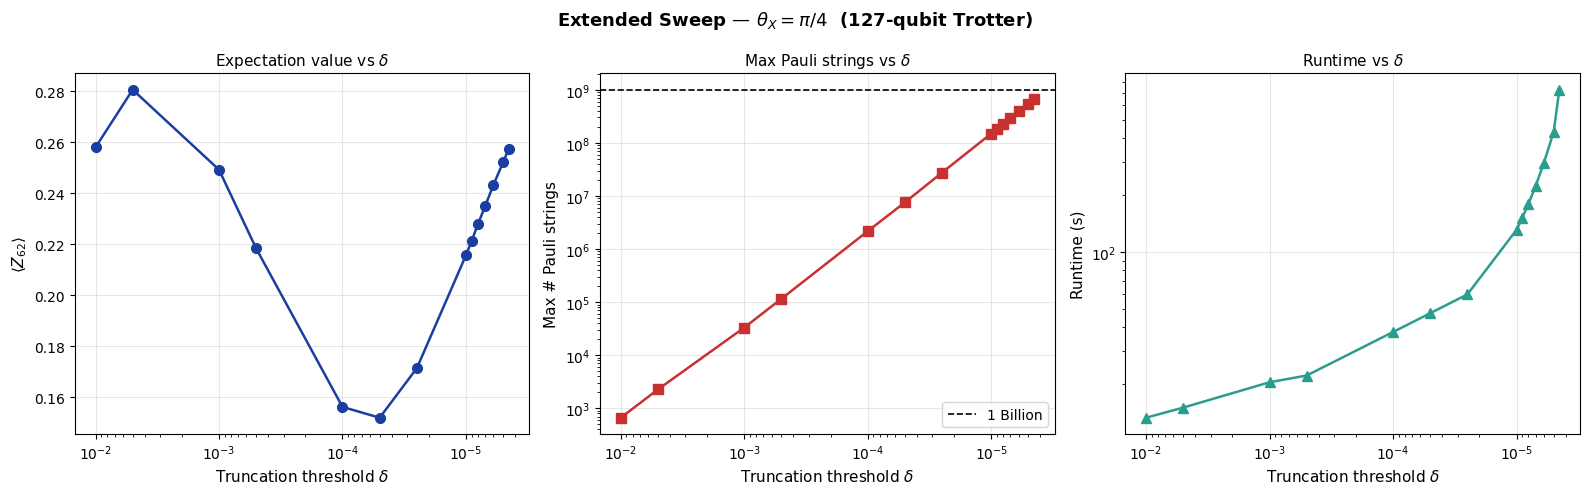

In [41]:
# ── Plot ──────────────────────────────────────────────────────────────────────
if ok:
    ds  = [r["delta"]            for r in ok]
    evs = [r["expectation_value"] for r in ok]
    mps = [r["max_paulis"]        for r in ok]
    rts = [r["run_time_s"]        for r in ok]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(r"Extended Sweep — $\theta_X = \pi/4$  (127-qubit Trotter)",
                 fontsize=13, fontweight="bold")

    RED = "#C93030"

    ax = axes[0]
    ax.plot(ds, evs, color="#1B3FA0", marker="o", markersize=7, linewidth=1.8)
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel(r"Truncation threshold $\delta$", fontsize=11)
    ax.set_ylabel(r"$\langle Z_{62} \rangle$", fontsize=11)
    ax.set_title(r"Expectation value vs $\delta$", fontsize=11)
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(ds, mps, color=RED, marker="s", markersize=7, linewidth=1.8)
    ax.axhline(BILLION, color="black", linestyle="--", linewidth=1.2, label="1 Billion")
    for d, p in zip(ds, mps):
        if p >= BILLION:
            ax.axvline(d, color=RED, alpha=0.15, linewidth=6)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel(r"Truncation threshold $\delta$", fontsize=11)
    ax.set_ylabel("Max # Pauli strings", fontsize=11)
    ax.set_title(r"Max Pauli strings vs $\delta$", fontsize=11)
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(ds, rts, color="#2A9D8F", marker="^", markersize=7, linewidth=1.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel(r"Truncation threshold $\delta$", fontsize=11)
    ax.set_ylabel("Runtime (s)", fontsize=11)
    ax.set_title(r"Runtime vs $\delta$", fontsize=11)
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(os.path.dirname(OUTPUT_FILE), "pauli_sweep_extended.png"), dpi=180, bbox_inches="tight")
    print(f"Plot saved → {os.path.join(os.path.dirname(OUTPUT_FILE), 'pauli_sweep_extended.png')}")
    plt.show()